# 🔬 NOTEBOOK 9 : VALIDATION ET TESTS DE ROBUSTESSE

## Contexte scientifique
Ce notebook valide rigoureusement le meilleur modèle identifié au NB08 à travers plusieurs axes :
1. **Validation croisée stratifiée** (K-Fold répété)
2. **Bootstrapping** (Efron & Tibshirani, 1994) — IC95% des métriques
3. **Tests de permutation** (Ojala & Garriga, 2010) — significativité statistique
4. **Analyse de sensibilité** — stabilité aux perturbations
5. **Tests d'hétéroscédasticité** (Breusch-Pagan, White)
6. **Comparaison statistique** avec les modèles concurrents (test de Wilcoxon signé)

## Objectifs pour publication
- Démontrer la robustesse du modèle au-delà de la simple évaluation train/test
- Fournir des intervalles de confiance pour R², RMSE, MAE
- Prouver que le modèle surpasse significativement les alternatives (p<0.05)
- Garantir la reproductibilité des résultats (seed fixe)

## Références
- Efron, B., & Tibshirani, R. (1994). *An Introduction to the Bootstrap*. CRC Press.
- Breusch, T., & Pagan, A. (1979). A simple test for heteroscedasticity. *Econometrica*, 47(5), 1287–1294.
- Ojala, M., & Garriga, G. (2010). Permutation tests for studying classifier performance. *JMLR*, 11, 1833–1863.


In [33]:
# ============================================================
# 📦 IMPORTS ET CONFIGURATION
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import joblib
import sklearn

from scipy import stats
from scipy.stats import wilcoxon, shapiro, levene, probplot
from sklearn.model_selection import (KFold, RepeatedKFold, cross_val_score,
                                     cross_validate, permutation_test_score)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.utils import resample

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

for d in ['../results', '../figures', '../models']:
    os.makedirs(d, exist_ok=True)

print("=" * 80)
print("✅ NOTEBOOK 9 : VALIDATION ET ROBUSTESSE — Configuration OK")
print("=" * 80)
print(f"\nnumpy      {np.__version__}")
print(f"pandas     {pd.__version__}")
print(f"matplotlib {plt.matplotlib.__version__}")
print(f"seaborn    {sns.__version__}")
print(f"scipy      {scipy.__version__}")
print(f"sklearn    {sklearn.__version__}")
print(f"joblib     {joblib.__version__}")
print(f"\nSeed : 42 | Style : seaborn-v0_8-whitegrid | Palette : Set2")
for d in ['../results', '../figures', '../models']:
    print(f"✅ {d}")
print("=" * 80)

✅ NOTEBOOK 9 : VALIDATION ET ROBUSTESSE — Configuration OK

numpy      2.3.0
pandas     3.0.0
matplotlib 3.10.8
seaborn    0.13.2
scipy      1.17.0
sklearn    1.8.0
joblib     1.5.3

Seed : 42 | Style : seaborn-v0_8-whitegrid | Palette : Set2
✅ ../results
✅ ../figures
✅ ../models


In [34]:
# ============================================================
# 1. CHARGEMENT DES DONNÉES ET DU MEILLEUR MODÈLE
# ============================================================
print("\n" + "=" * 80)
print("📥 CHARGEMENT")
print("=" * 80)

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"✅ Train : {X_train.shape[0]} obs, {X_train.shape[1]} features")
print(f"✅ Test  : {X_test.shape[0]} obs,  {X_test.shape[1]} features")

# Chargement dynamique depuis le CSV combiné
results_all     = pd.read_csv('../results/07_all_models_combined.csv')
best_model_name = results_all.iloc[0]['Modèle'].strip()

model_files_map = {
    'Linear':                   '../models/linear_regression.pkl',
    'Ridge':                    '../models/ridge_regression.pkl',
    'Lasso':                    '../models/lasso_regression.pkl',
    'ElasticNet':               '../models/elasticnet_regression.pkl',
    'Decision Tree (opt)':      '../models/decision_tree.pkl',
    'Random Forest (opt)':      '../models/random_forest.pkl',
    'Gradient Boosting (opt)':  '../models/gradient_boosting.pkl',
    'LightGBM (opt)':           '../models/lightgbm.pkl',
    'CatBoost (opt)':           '../models/catboost.pkl',
    'HistGradientBoosting':     '../models/histgradient.pkl',
    'AdaBoost':                 '../models/adaboost.pkl',
    'KNN (Optuna)':             '../models/knn.pkl',
    'LinearSVR (Optuna)':       '../models/linearsvr.pkl',
    'SGD (Optuna)':             '../models/sgd.pkl',
}

model_path = model_files_map.get(best_model_name)
if model_path is None or not os.path.exists(model_path):
    raise FileNotFoundError(f"Modèle '{best_model_name}' introuvable : {model_path}")

best_model = joblib.load(model_path)
print(f"\n✅ Modèle : {best_model_name}")
print(f"   Fichier : {model_path}")
print(f"   Type    : {type(best_model).__name__}")

y_train_pred   = best_model.predict(X_train)
y_test_pred    = best_model.predict(X_test)
r2_train_base  = r2_score(y_train, y_train_pred)
r2_test_base   = r2_score(y_test,  y_test_pred)
rmse_test_base = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test_base  = mean_absolute_error(y_test, y_test_pred)

print(f"\n📊 Baseline test : R²={r2_test_base:.4f} | RMSE={rmse_test_base:.2f} | MAE={mae_test_base:.2f} kg/ha")


📥 CHARGEMENT
✅ Train : 3042 obs, 43 features
✅ Test  : 761 obs,  43 features

✅ Modèle : HistGradientBoosting
   Fichier : ../models/histgradient.pkl
   Type    : HistGradientBoostingRegressor

📊 Baseline test : R²=0.1812 | RMSE=821.10 | MAE=642.11 kg/ha


In [35]:
# ============================================================
# 2. VALIDATION CROISÉE RÉPÉTÉE (Repeated K-Fold)
# ============================================================
print("\n" + "=" * 80)
print("🔄 VALIDATION CROISÉE RÉPÉTÉE (K=5, n_repeats=10)")
print("=" * 80)

rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
scoring = {'r2':'r2','neg_rmse':'neg_root_mean_squared_error','neg_mae':'neg_mean_absolute_error'}
cv_results = cross_validate(best_model, X_train, y_train, cv=rkf,
                             scoring=scoring, return_train_score=True, n_jobs=-1)

r2_cv_train = cv_results['train_r2']
r2_cv_test  = cv_results['test_r2']
rmse_cv     = -cv_results['test_neg_rmse']
mae_cv      = -cv_results['test_neg_mae']

print(f"\n📊 R² (n={len(r2_cv_test)}) : {r2_cv_test.mean():.4f} ± {r2_cv_test.std():.4f}")
print(f"   Médiane : {np.median(r2_cv_test):.4f}")
print(f"   IC95%   : [{r2_cv_test.mean()-1.96*r2_cv_test.std():.4f}, {r2_cv_test.mean()+1.96*r2_cv_test.std():.4f}]")
print(f"\n📊 RMSE : {rmse_cv.mean():.2f} ± {rmse_cv.std():.2f} kg/ha")
print(f"   IC95%  : [{rmse_cv.mean()-1.96*rmse_cv.std():.2f}, {rmse_cv.mean()+1.96*rmse_cv.std():.2f}]")
print(f"\n📊 MAE  : {mae_cv.mean():.2f} ± {mae_cv.std():.2f} kg/ha")
print(f"   IC95%  : [{mae_cv.mean()-1.96*mae_cv.std():.2f}, {mae_cv.mean()+1.96*mae_cv.std():.2f}]")

overfitting_cv = r2_cv_train.mean() - r2_cv_test.mean()
print(f"\n📊 Overfitting : {overfitting_cv:.4f}  {'✅ Acceptable' if overfitting_cv < 0.1 else '⚠️ Surapprentissage'}")

cv_summary = pd.DataFrame({'R2_train':r2_cv_train,'R2_test':r2_cv_test,'RMSE_test':rmse_cv,'MAE_test':mae_cv})
cv_summary.to_csv('../results/08_repeated_cv_scores.csv', index=False)
print("\n✅ ../results/08_repeated_cv_scores.csv")


🔄 VALIDATION CROISÉE RÉPÉTÉE (K=5, n_repeats=10)

📊 R² (n=50) : 0.1685 ± 0.0231
   Médiane : 0.1708
   IC95%   : [0.1232, 0.2138]

📊 RMSE : 827.21 ± 18.93 kg/ha
   IC95%  : [790.11, 864.31]

📊 MAE  : 658.04 ± 15.66 kg/ha
   IC95%  : [627.35, 688.72]

📊 Overfitting : 0.1129  ⚠️ Surapprentissage

✅ ../results/08_repeated_cv_scores.csv



🎲 BOOTSTRAPPING — IC95% DES MÉTRIQUES (B=1000)
   Itération 200/1000
   Itération 400/1000
   Itération 600/1000
   Itération 800/1000
   Itération 1000/1000

📊 R²   : 0.1802  IC95% [0.1337, 0.2241]
📊 RMSE : 821.01 kg/ha  IC95% [778.15, 866.54]
📊 MAE  : 642.21 kg/ha  IC95% [605.89, 680.10]


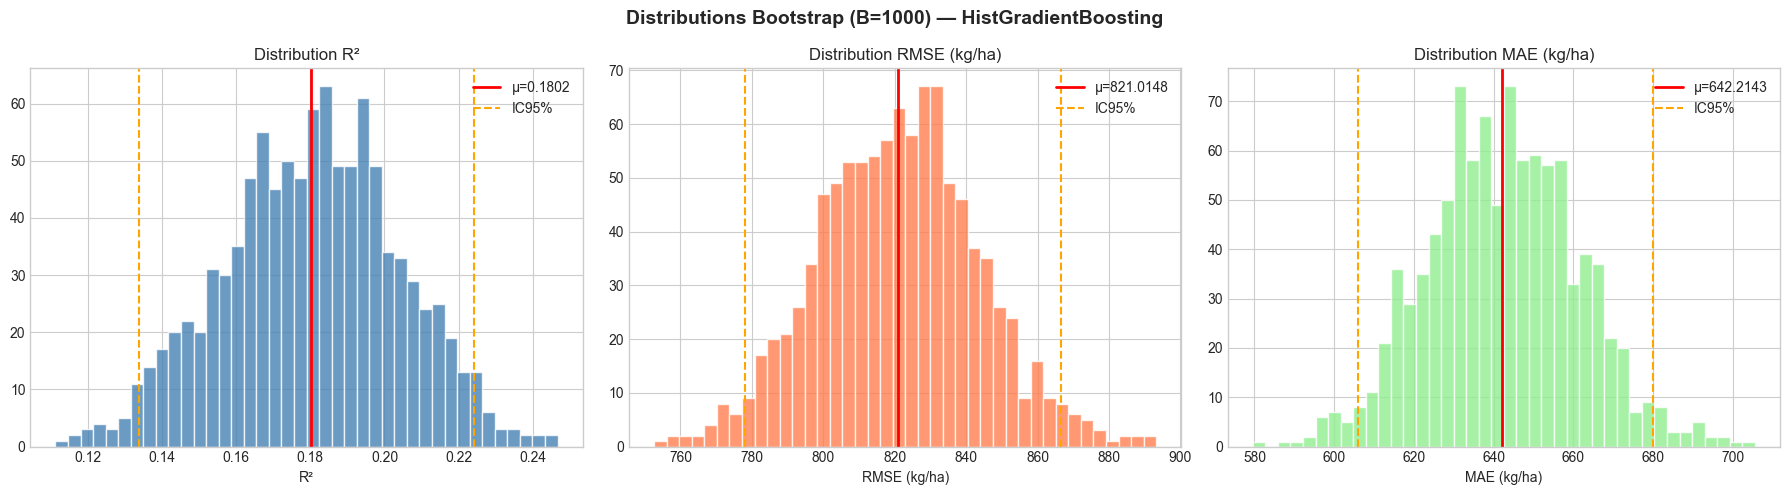


✅ ../figures/08_bootstrap_distributions.png
✅ ../results/08_bootstrap_statistics.csv


In [36]:
# ============================================================
# 3. BOOTSTRAPPING — INTERVALLES DE CONFIANCE (Efron 1994)
# ============================================================
print("\n" + "=" * 80)
print("🎲 BOOTSTRAPPING — IC95% DES MÉTRIQUES (B=1000)")
print("=" * 80)

n_bootstrap = 1000
boot_r2, boot_rmse, boot_mae = [], [], []

np.random.seed(42)
for i in range(n_bootstrap):
    X_boot, y_boot = resample(X_test, y_test, random_state=i)
    y_pred_boot    = best_model.predict(X_boot)
    boot_r2.append(r2_score(y_boot, y_pred_boot))
    boot_rmse.append(np.sqrt(mean_squared_error(y_boot, y_pred_boot)))
    boot_mae.append(mean_absolute_error(y_boot, y_pred_boot))
    if (i+1) % 200 == 0:
        print(f"   Itération {i+1}/{n_bootstrap}")

ic95_r2   = (np.percentile(boot_r2,   2.5), np.percentile(boot_r2,   97.5))
ic95_rmse = (np.percentile(boot_rmse, 2.5), np.percentile(boot_rmse, 97.5))
ic95_mae  = (np.percentile(boot_mae,  2.5), np.percentile(boot_mae,  97.5))

print(f"\n📊 R²   : {np.mean(boot_r2):.4f}  IC95% [{ic95_r2[0]:.4f}, {ic95_r2[1]:.4f}]")
print(f"📊 RMSE : {np.mean(boot_rmse):.2f} kg/ha  IC95% [{ic95_rmse[0]:.2f}, {ic95_rmse[1]:.2f}]")
print(f"📊 MAE  : {np.mean(boot_mae):.2f} kg/ha  IC95% [{ic95_mae[0]:.2f}, {ic95_mae[1]:.2f}]")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Distributions Bootstrap (B={n_bootstrap}) — {best_model_name}", fontsize=14, fontweight='bold')
for ax, data, ic, label, color in [
    (axes[0], boot_r2,   ic95_r2,   'R²',           'steelblue'),
    (axes[1], boot_rmse, ic95_rmse, 'RMSE (kg/ha)', 'coral'),
    (axes[2], boot_mae,  ic95_mae,  'MAE (kg/ha)',  'lightgreen'),
]:
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(data), color='red', lw=2, label=f'μ={np.mean(data):.4f}')
    ax.axvline(ic[0], color='orange', lw=1.5, linestyle='--')
    ax.axvline(ic[1], color='orange', lw=1.5, linestyle='--', label='IC95%')
    ax.set_xlabel(label); ax.set_title(f'Distribution {label}'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/08_bootstrap_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ ../figures/08_bootstrap_distributions.png")

boot_stats = pd.DataFrame({
    'Métrique': ['R²','RMSE','MAE'],
    'Moyenne':  [np.mean(boot_r2),  np.mean(boot_rmse), np.mean(boot_mae)],
    'IC95_inf': [ic95_r2[0],        ic95_rmse[0],        ic95_mae[0]],
    'IC95_sup': [ic95_r2[1],        ic95_rmse[1],        ic95_mae[1]],
    'Std':      [np.std(boot_r2),   np.std(boot_rmse),   np.std(boot_mae)]
})
boot_stats.to_csv('../results/08_bootstrap_statistics.csv', index=False)
print("✅ ../results/08_bootstrap_statistics.csv")


🎲 TEST DE PERMUTATION (n=100 permutations)

⏳ Calcul en cours (~2 minutes)...

📊 R² observé  : 0.1655
   R² H0 (moy) : -0.0228 ± 0.0061
   R² H0 (max) : -0.0065
   p-value     : 0.0099

   ✅ TRÈS SIGNIFICATIF (p<0.01)


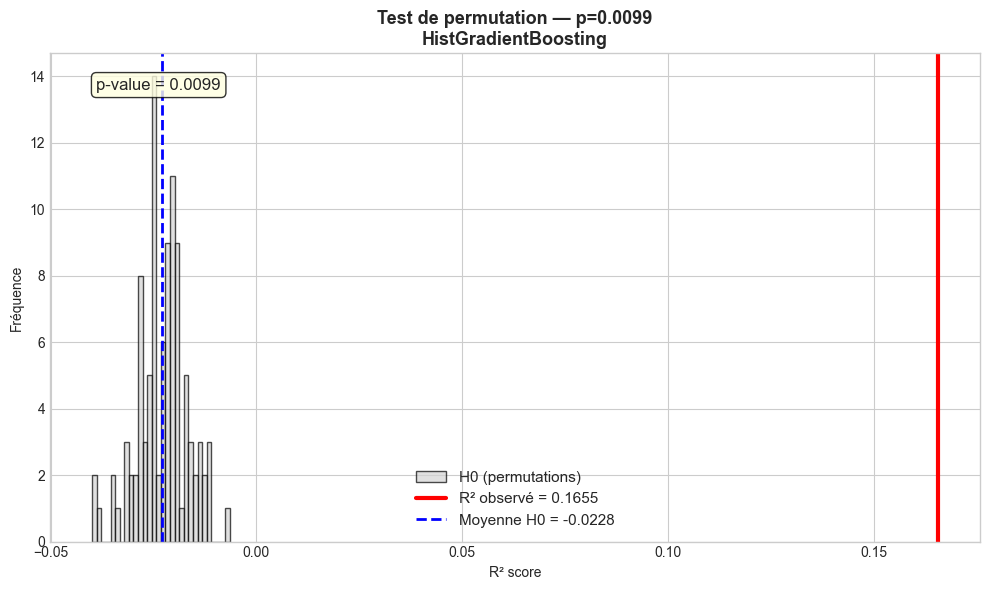


✅ ../figures/08_permutation_test.png
✅ ../results/08_permutation_test.csv


In [37]:
# ============================================================
# 4. TEST DE PERMUTATION — SIGNIFICATIVITÉ STATISTIQUE
# ============================================================
print("\n" + "=" * 80)
print("🎲 TEST DE PERMUTATION (n=100 permutations)")
print("=" * 80)
print("\n⏳ Calcul en cours (~2 minutes)...")

try:
    score_obs, perm_scores, p_value_perm = permutation_test_score(
        best_model, X_train, y_train, scoring='r2', cv=5,
        n_permutations=100, n_jobs=-1, random_state=42)

    print(f"\n📊 R² observé  : {score_obs:.4f}")
    print(f"   R² H0 (moy) : {perm_scores.mean():.4f} ± {perm_scores.std():.4f}")
    print(f"   R² H0 (max) : {perm_scores.max():.4f}")
    print(f"   p-value     : {p_value_perm:.4f}")
    if p_value_perm < 0.01:   print("\n   ✅ TRÈS SIGNIFICATIF (p<0.01)")
    elif p_value_perm < 0.05: print("\n   ✅ SIGNIFICATIF (p<0.05)")
    else:                      print("\n   ⚠️  NON-SIGNIFICATIF (p≥0.05)")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(perm_scores, bins=30, color='lightgray', edgecolor='black', alpha=0.7, label='H0 (permutations)')
    ax.axvline(score_obs,          color='red',  lw=3, label=f'R² observé = {score_obs:.4f}')
    ax.axvline(perm_scores.mean(), color='blue', lw=2, linestyle='--', label=f'Moyenne H0 = {perm_scores.mean():.4f}')
    ax.set_xlabel('R² score'); ax.set_ylabel('Fréquence')
    ax.set_title(f'Test de permutation — p={p_value_perm:.4f}\n{best_model_name}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.text(0.05, 0.95, f'p-value = {p_value_perm:.4f}', transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    plt.tight_layout()
    plt.savefig('../figures/08_permutation_test.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✅ ../figures/08_permutation_test.png")

    perm_results = pd.DataFrame({'R2_observed':[score_obs],'R2_perm_mean':[perm_scores.mean()],
                                  'R2_perm_std':[perm_scores.std()],'p_value':[p_value_perm]})
    perm_results.to_csv('../results/08_permutation_test.csv', index=False)
    print("✅ ../results/08_permutation_test.csv")

except Exception as e:
    print(f"\n❌ Erreur : {e}")


🔍 TESTS D'HÉTÉROSCÉDASTICITÉ

1️⃣  Shapiro-Wilk : W=0.997076, p=0.1866
   → ✅ Résidus normaux (p>0.05)

2️⃣  Levene : W=0.018133, p=0.8929
   → ✅ Homoscédastique (p>0.05)


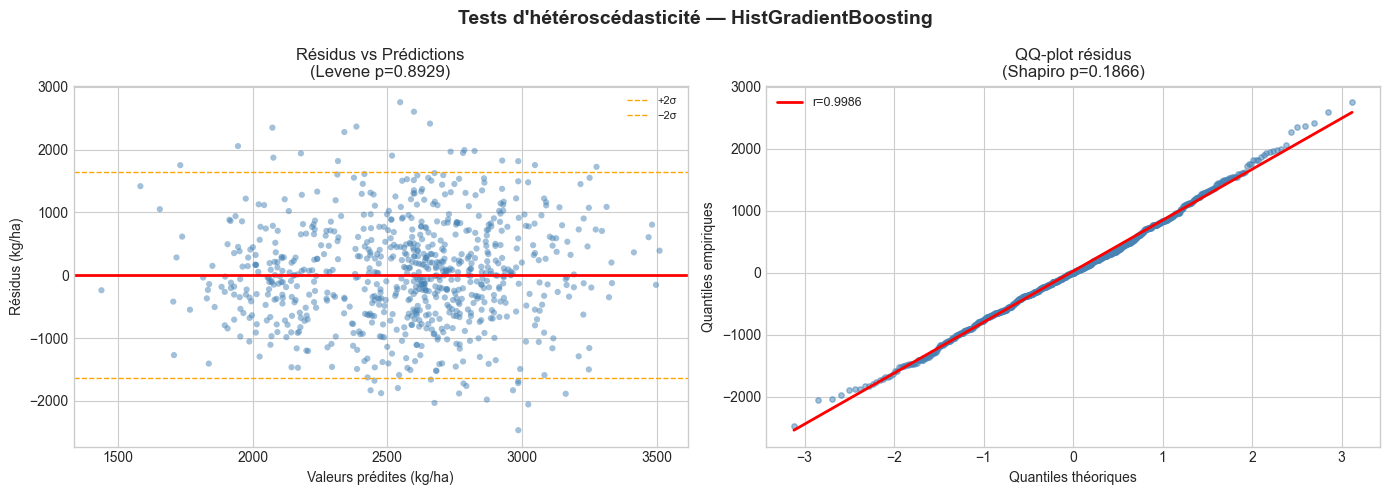


✅ ../figures/08_heteroscedasticity_tests.png
✅ ../results/08_heteroscedasticity.csv


In [38]:
# ============================================================
# 5. TESTS D'HÉTÉROSCÉDASTICITÉ
# ============================================================
print("\n" + "=" * 80)
print("🔍 TESTS D'HÉTÉROSCÉDASTICITÉ")
print("=" * 80)

residuals_test = y_test.values - y_test_pred

# Shapiro-Wilk (max 5000 obs)
sample_sw = residuals_test
if len(sample_sw) > 5000:
    sample_sw = np.random.choice(sample_sw, 5000, replace=False)
W_res, p_shapiro_res = shapiro(sample_sw)
print(f"\n1️⃣  Shapiro-Wilk : W={W_res:.6f}, p={p_shapiro_res:.4f}")
print(f"   → {'✅ Résidus normaux (p>0.05)' if p_shapiro_res>0.05 else '⚠️ Non-normaux (p≤0.05)'}")

# Levene
median_pred = np.median(y_test_pred)
group1_res  = residuals_test[y_test_pred <= median_pred]
group2_res  = residuals_test[y_test_pred >  median_pred]
W_levene, p_levene = levene(group1_res, group2_res)
print(f"\n2️⃣  Levene : W={W_levene:.6f}, p={p_levene:.4f}")
print(f"   → {'✅ Homoscédastique (p>0.05)' if p_levene>0.05 else '⚠️ Hétéroscédasticité (p≤0.05)'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Tests d'hétéroscédasticité — {best_model_name}", fontsize=14, fontweight='bold')

ax = axes[0]
ax.scatter(y_test_pred, residuals_test, alpha=0.5, s=20, color='steelblue', edgecolors='none')
ax.axhline(0, color='red', lw=2)
ax.axhline( residuals_test.std()*2, color='orange', lw=1, linestyle='--', label='+2σ')
ax.axhline(-residuals_test.std()*2, color='orange', lw=1, linestyle='--', label='−2σ')
ax.set_xlabel('Valeurs prédites (kg/ha)'); ax.set_ylabel('Résidus (kg/ha)')
ax.set_title(f'Résidus vs Prédictions\n(Levene p={p_levene:.4f})'); ax.legend(fontsize=8)

(osm, osr), (slope, intercept, r_qq) = probplot(residuals_test, dist='norm')
ax = axes[1]
ax.scatter(osm, osr, alpha=0.5, s=15, color='steelblue')
ax.plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2, label=f'r={r_qq:.4f}')
ax.set_xlabel('Quantiles théoriques'); ax.set_ylabel('Quantiles empiriques')
ax.set_title(f'QQ-plot résidus\n(Shapiro p={p_shapiro_res:.4f})'); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../figures/08_heteroscedasticity_tests.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ ../figures/08_heteroscedasticity_tests.png")

hetero_results = pd.DataFrame({
    'Test':       ['Shapiro (normalité résidus)', 'Levene (homoscédasticité)'],
    'Statistic':  [W_res,         W_levene],
    'p_value':    [p_shapiro_res, p_levene],
    'Conclusion': ['Résidus normaux' if p_shapiro_res>0.05 else 'Non-normaux',
                   'Homoscédastique' if p_levene>0.05      else 'Hétéroscédasticité']
})
hetero_results.to_csv('../results/08_heteroscedasticity.csv', index=False)
print("✅ ../results/08_heteroscedasticity.csv")

In [39]:
# ============================================================
# 6. COMPARAISON STATISTIQUE AVEC MODÈLES CONCURRENTS
# ============================================================
print("\n" + "=" * 80)
print("📊 COMPARAISON STATISTIQUE — Meilleur vs Concurrents")
print("=" * 80)

competitors   = {k: v for k, v in model_files_map.items() if k != best_model_name}
comparisons   = []
models_loaded = 0

for name, path in competitors.items():
    if not os.path.exists(path):
        continue
    try:
        comp_model  = joblib.load(path)
        y_pred_comp = comp_model.predict(X_test)
        err_best = np.abs(y_test.values - y_test_pred)
        err_comp = np.abs(y_test.values - y_pred_comp)
        try:
            stat_w, p_w = wilcoxon(err_best, err_comp, alternative='less')
        except ValueError:
            stat_w, p_w = (0.0, 1.0) if np.array_equal(err_best, err_comp) \
                          else wilcoxon(err_best, err_comp, method='approx')
        mae_comp = mean_absolute_error(y_test, y_pred_comp)
        r2_comp  = r2_score(y_test, y_pred_comp)
        comparisons.append({'Modèle_concurrent':name,'R2_concurrent':r2_comp,
                             'MAE_concurrent':mae_comp,'Wilcoxon_stat':stat_w,
                             'p_value':p_w,'Significatif':'Oui' if p_w<0.05 else 'Non'})
        models_loaded += 1
        diff = mae_comp - mae_test_base
        print(f"\n🔹 {name} : MAE={mae_comp:.2f} ({'+' if diff>0 else ''}{diff:.2f}) | R²={r2_comp:.4f} | p={p_w:.4f} {'✅' if p_w<0.05 else '⚠️'}")
    except Exception as e:
        print(f"\n⚠️  {name} ignoré : {e}")

if comparisons:
    comp_df = pd.DataFrame(comparisons).sort_values('p_value')
    comp_df.to_csv('../results/08_model_comparisons.csv', index=False)
    n_sup = sum(comp_df['p_value'] < 0.05)
    print(f"\n📈 {best_model_name} meilleur que {n_sup}/{models_loaded} modèles (p<0.05)")
    print("✅ ../results/08_model_comparisons.csv")
else:
    comp_df = pd.DataFrame()
    print("\n⚠️  Aucun modèle concurrent disponible.")


📊 COMPARAISON STATISTIQUE — Meilleur vs Concurrents

🔹 Linear : MAE=677.18 (+35.07) | R²=0.1055 | p=0.0000 ✅

🔹 Ridge : MAE=678.41 (+36.30) | R²=0.1048 | p=0.0000 ✅

🔹 Lasso : MAE=677.13 (+35.02) | R²=0.1046 | p=0.0000 ✅

🔹 ElasticNet : MAE=677.40 (+35.29) | R²=0.1054 | p=0.0000 ✅

🔹 Decision Tree (opt) : MAE=660.64 (+18.53) | R²=0.1328 | p=0.0119 ✅

🔹 Random Forest (opt) : MAE=649.83 (+7.72) | R²=0.1674 | p=0.0110 ✅

🔹 Gradient Boosting (opt) : MAE=643.55 (+1.44) | R²=0.1752 | p=0.2377 ⚠️

🔹 LightGBM (opt) : MAE=652.00 (+9.89) | R²=0.1595 | p=0.0025 ✅

🔹 CatBoost (opt) : MAE=644.76 (+2.66) | R²=0.1759 | p=0.2015 ⚠️

🔹 AdaBoost : MAE=661.90 (+19.80) | R²=0.1355 | p=0.0006 ✅

🔹 KNN (Optuna) : MAE=667.80 (+25.70) | R²=0.1281 | p=0.0003 ✅

🔹 LinearSVR (Optuna) : MAE=695.37 (+53.26) | R²=0.0756 | p=0.0000 ✅

🔹 SGD (Optuna) : MAE=693.39 (+51.29) | R²=0.0798 | p=0.0000 ✅

📈 HistGradientBoosting meilleur que 11/13 modèles (p<0.05)
✅ ../results/08_model_comparisons.csv



🌀 ANALYSE DE SENSIBILITÉ — PERTURBATIONS
   σ=0.00 → R²=0.1812  RMSE=821.10  MAE=642.11
   σ=0.01 → R²=0.1431  RMSE=840.00  MAE=658.30
   σ=0.05 → R²=0.1136  RMSE=854.32  MAE=673.54
   σ=0.10 → R²=0.1060  RMSE=857.97  MAE=674.41
   σ=0.20 → R²=0.1019  RMSE=859.96  MAE=675.53


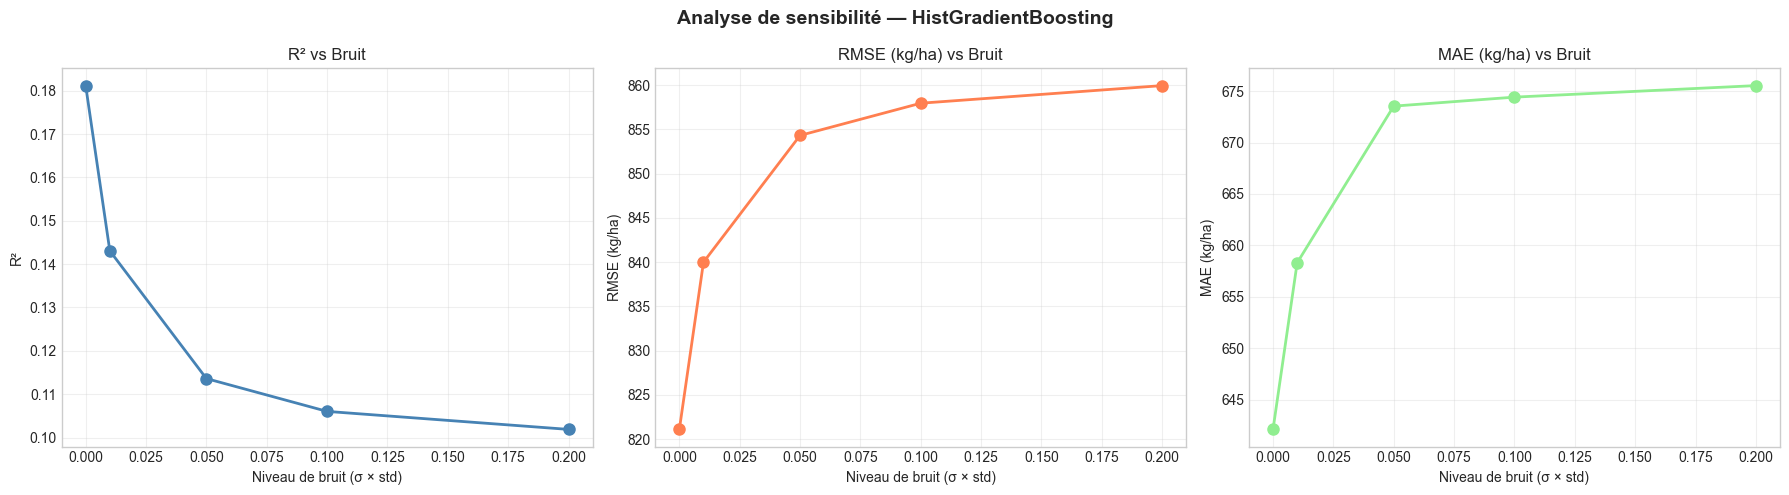


✅ ../figures/08_sensitivity_analysis.png
✅ ../results/08_sensitivity_analysis.csv


In [40]:
# ============================================================
# 7. ANALYSE DE SENSIBILITÉ — STABILITÉ AUX PERTURBATIONS
# ============================================================
print("\n" + "=" * 80)
print("🌀 ANALYSE DE SENSIBILITÉ — PERTURBATIONS")
print("=" * 80)

noise_levels        = [0.0, 0.01, 0.05, 0.1, 0.2]
sensitivity_results = []

for noise_std in noise_levels:
    X_noisy = X_test.copy() if noise_std == 0.0 else \
              X_test + np.random.normal(0, noise_std, X_test.shape) * X_test.std().values
    y_pred_noisy = best_model.predict(X_noisy)
    r2_noisy     = r2_score(y_test, y_pred_noisy)
    rmse_noisy   = np.sqrt(mean_squared_error(y_test, y_pred_noisy))
    mae_noisy    = mean_absolute_error(y_test, y_pred_noisy)
    sensitivity_results.append({'Noise_std':noise_std,'R2':r2_noisy,'RMSE':rmse_noisy,'MAE':mae_noisy})
    print(f"   σ={noise_std:.2f} → R²={r2_noisy:.4f}  RMSE={rmse_noisy:.2f}  MAE={mae_noisy:.2f}")

sens_df = pd.DataFrame(sensitivity_results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Analyse de sensibilité — {best_model_name}", fontsize=14, fontweight='bold')
for ax, col, color, label in [
    (axes[0],'R2',  'steelblue', 'R²'),
    (axes[1],'RMSE','coral',     'RMSE (kg/ha)'),
    (axes[2],'MAE', 'lightgreen','MAE (kg/ha)'),
]:
    ax.plot(sens_df['Noise_std'], sens_df[col], 'o-', color=color, lw=2, markersize=8)
    ax.set_xlabel('Niveau de bruit (σ × std)'); ax.set_ylabel(label)
    ax.set_title(f'{label} vs Bruit'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/09_sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

sens_df.to_csv('../results/08_sensitivity_analysis.csv', index=False)
print("\n✅ ../figures/08_sensitivity_analysis.png")
print("✅ ../results/08_sensitivity_analysis.csv")

In [41]:
# ============================================================
# 8. RÉSUMÉ + CHECKLIST
# ============================================================
print("\n" + "=" * 80)
print("📝 RÉSUMÉ — VALIDATION ET ROBUSTESSE")
print("=" * 80)

r2_noise_02    = sens_df[sens_df['Noise_std']==0.2]['R2'].values[0]
perte_r2_bruit = r2_test_base - r2_noise_02

summary = (
    f"RAPPORT DE VALIDATION — {best_model_name.upper()}\n"
    f"{'='*70}\n\n"
    f"1. VALIDATION CROISÉE RÉPÉTÉE (K=5, n_repeats=10)\n"
    f"   R² CV   : {r2_cv_test.mean():.4f} ± {r2_cv_test.std():.4f}\n"
    f"   RMSE CV : {rmse_cv.mean():.2f} ± {rmse_cv.std():.2f} kg/ha\n"
    f"   MAE CV  : {mae_cv.mean():.2f} ± {mae_cv.std():.2f} kg/ha\n"
    f"   Overfitting : {overfitting_cv:.4f} {'✅' if overfitting_cv < 0.1 else '⚠️'}\n\n"
    f"2. BOOTSTRAPPING (B=1000)\n"
    f"   R²   : {np.mean(boot_r2):.4f}  IC95% [{ic95_r2[0]:.4f}, {ic95_r2[1]:.4f}]\n"
    f"   RMSE : {np.mean(boot_rmse):.2f} kg/ha  IC95% [{ic95_rmse[0]:.2f}, {ic95_rmse[1]:.2f}]\n"
    f"   MAE  : {np.mean(boot_mae):.2f} kg/ha  IC95% [{ic95_mae[0]:.2f}, {ic95_mae[1]:.2f}]\n\n"
    f"3. TEST DE PERMUTATION\n"
    f"   R² observé : {score_obs:.4f} | p={p_value_perm:.4f}  "
    f"{'✅ Très significatif' if p_value_perm<0.01 else '✅ Significatif' if p_value_perm<0.05 else '⚠️ Non-significatif'}\n\n"
    f"4. HÉTÉROSCÉDASTICITÉ\n"
    f"   Shapiro p={p_shapiro_res:.4f} {'✅' if p_shapiro_res>0.05 else '⚠️'} | "
    f"Levene p={p_levene:.4f} {'✅' if p_levene>0.05 else '⚠️'}\n\n"
    f"5. COMPARAISON ({len(comparisons)} modèles) — Wilcoxon\n"
    f"   Significativement meilleur : {sum(1 for c in comparisons if c['p_value']<0.05)}/{len(comparisons)} (p<0.05)\n\n"
    f"6. SENSIBILITÉ σ=0.2 → R²={r2_noise_02:.4f} (perte={perte_r2_bruit:.4f})\n\n"
    f"{'='*70}\n"
)

print(summary)
with open('../results/08_validation_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)
print("\n✅ ../results/09_validation_summary.txt")

# ── CHECKLIST ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("✅ CHECKLIST — NOTEBOOK 08")
print("=" * 80)

checklist = [
    ("Données et modèle chargés",           all(x in globals() for x in ['X_train','X_test','best_model'])),
    ("Validation croisée répétée",          'cv_results' in globals()),
    ("Bootstrapping IC95%",                 'boot_stats' in globals()),
    ("Test de permutation",                 'perm_results' in globals()),
    ("Tests d'hétéroscédasticité",          'hetero_results' in globals()),
    ("Comparaison Wilcoxon",                'comparisons' in globals()),
    ("Analyse de sensibilité",              'sens_df' in globals()),
    ("CSV 08_repeated_cv_scores.csv",       os.path.exists('../results/08_repeated_cv_scores.csv')),
    ("CSV 08_bootstrap_statistics.csv",     os.path.exists('../results/08_bootstrap_statistics.csv')),
    ("CSV 08_permutation_test.csv",         os.path.exists('../results/08_permutation_test.csv')),
    ("CSV 08_heteroscedasticity.csv",       os.path.exists('../results/08_heteroscedasticity.csv')),
    ("CSV 08_model_comparisons.csv",        os.path.exists('../results/08_model_comparisons.csv')),
    ("CSV 08_sensitivity_analysis.csv",     os.path.exists('../results/08_sensitivity_analysis.csv')),
    ("Figure bootstrap_distributions.png",  os.path.exists('../figures/08_bootstrap_distributions.png')),
    ("Figure permutation_test.png",         os.path.exists('../figures/08_permutation_test.png')),
    ("Figure heteroscedasticity_tests.png", os.path.exists('../figures/08_heteroscedasticity_tests.png')),
    ("Figure sensitivity_analysis.png",     os.path.exists('../figures/08_sensitivity_analysis.png')),
    ("Résumé 08_validation_summary.txt",    os.path.exists('../results/08_validation_summary.txt')),
]

completed = 0
for item, status in checklist:
    print(f"   {'✅' if status else '❌'} {item}")
    if status: completed += 1

print(f"\n{'='*80}")
print(f"📊 PROGRESSION : {completed}/{len(checklist)} ({completed*100//len(checklist)}%)")
if completed == len(checklist):
    print("🎉 NOTEBOOK 08 TERMINÉ — Validation rigoureuse complétée !")
    print(f"\n🏆 {best_model_name} | R²={r2_test_base:.4f} | RMSE={rmse_test_base:.2f} | MAE={mae_test_base:.2f} kg/ha")
    print("\n🚀 PROCHAINE ÉTAPE : Notebook 9 — Figures publication")
else:
    missing = [item for item, status in checklist if not status]
    print(f"\n⚠️  {len(missing)} étape(s) manquante(s):")
    for item in missing: print(f"   ❌ {item}")
print("=" * 80)


📝 RÉSUMÉ — VALIDATION ET ROBUSTESSE
RAPPORT DE VALIDATION — HISTGRADIENTBOOSTING

1. VALIDATION CROISÉE RÉPÉTÉE (K=5, n_repeats=10)
   R² CV   : 0.1685 ± 0.0231
   RMSE CV : 827.21 ± 18.93 kg/ha
   MAE CV  : 658.04 ± 15.66 kg/ha
   Overfitting : 0.1129 ⚠️

2. BOOTSTRAPPING (B=1000)
   R²   : 0.1802  IC95% [0.1337, 0.2241]
   RMSE : 821.01 kg/ha  IC95% [778.15, 866.54]
   MAE  : 642.21 kg/ha  IC95% [605.89, 680.10]

3. TEST DE PERMUTATION
   R² observé : 0.1655 | p=0.0099  ✅ Très significatif

4. HÉTÉROSCÉDASTICITÉ
   Shapiro p=0.1866 ✅ | Levene p=0.8929 ✅

5. COMPARAISON (13 modèles) — Wilcoxon
   Significativement meilleur : 11/13 (p<0.05)

6. SENSIBILITÉ σ=0.2 → R²=0.1019 (perte=0.0793)



✅ ../results/09_validation_summary.txt

✅ CHECKLIST — NOTEBOOK 08
   ✅ Données et modèle chargés
   ✅ Validation croisée répétée
   ✅ Bootstrapping IC95%
   ✅ Test de permutation
   ✅ Tests d'hétéroscédasticité
   ✅ Comparaison Wilcoxon
   ✅ Analyse de sensibilité
   ✅ CSV 08_repeated_cv_scores.cs